# 1. Import libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# 2. Load dataset

In [2]:
df = pd.read_csv("student_combined.csv")

df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,source
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mat
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mat


In [4]:
df.shape

(1044, 34)

In [5]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'source'],
      dtype='object')

# 3. Data Understanding

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

In [7]:
df.isnull().sum()


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
source        0
dtype: int64

In [8]:
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


# 4. Exploratory Data Analysis (EDA)

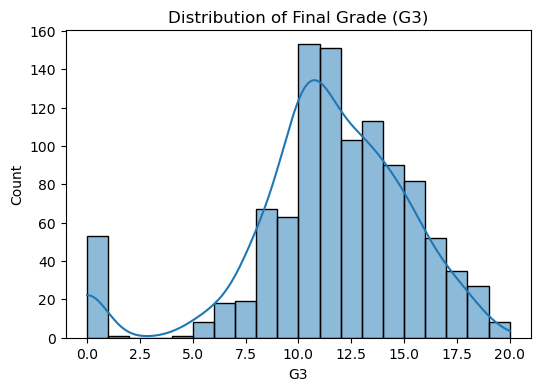

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df["G3"], bins=20, kde=True)
plt.title("Distribution of Final Grade (G3)")
plt.show()


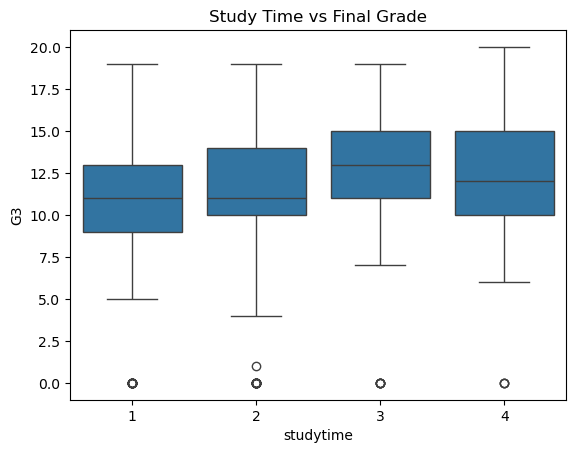

In [10]:
sns.boxplot(x="studytime", y="G3", data=df)
plt.title("Study Time vs Final Grade")
plt.show()


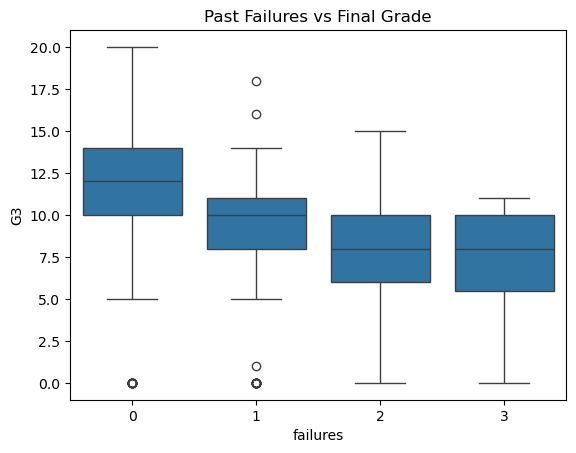

In [11]:
sns.boxplot(x="failures", y="G3", data=df)
plt.title("Past Failures vs Final Grade")
plt.show()


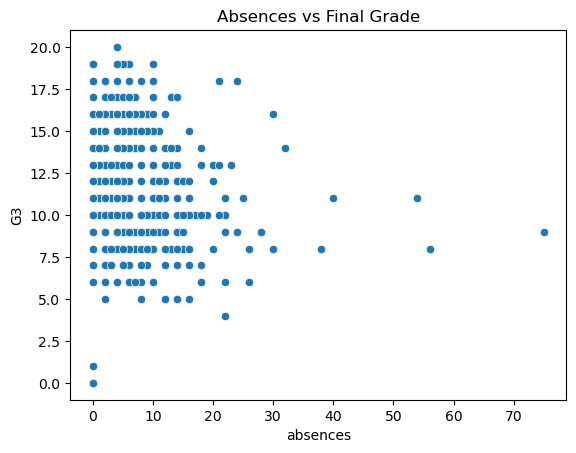

In [12]:
sns.scatterplot(x="absences", y="G3", data=df)
plt.title("Absences vs Final Grade")
plt.show()


<Figure size 1200x800 with 0 Axes>

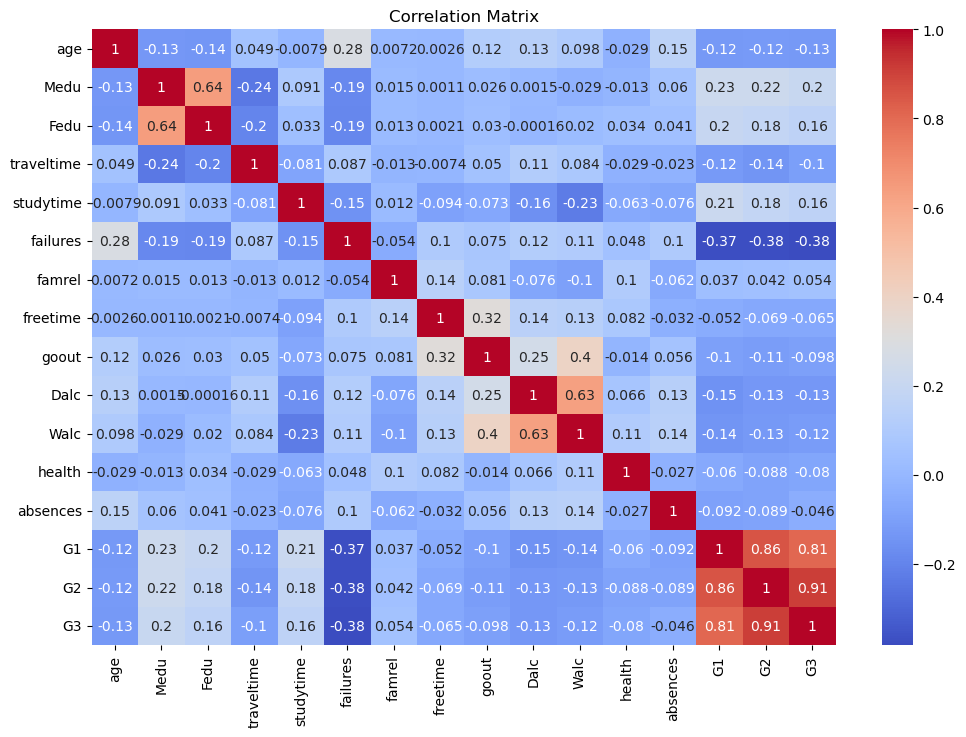

In [14]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()



# 5. Prepare Data for Machine Learning

In [15]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,source_por
0,18,4,4,2,2,0,4,3,4,1,...,False,True,False,False,False,True,True,False,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,True,False,False,False,True,True,False,False
2,15,1,1,1,2,3,4,3,2,2,...,False,True,False,True,False,True,True,True,False,False
3,15,4,2,1,3,0,3,2,2,1,...,False,False,True,True,True,True,True,True,True,False
4,16,3,3,1,2,0,4,3,2,1,...,False,False,True,True,False,True,True,False,False,False


In [16]:
df_encoded.columns


Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T',
       'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher',
       'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher',
       'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother',
       'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes',
       'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes',
       'romantic_yes', 'source_por'],
      dtype='object')

# 6. Regression Model (Predict Final Grade G3)

In [17]:
X = df_encoded.drop("G3", axis=1)
y = df_encoded["G3"]


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 7. Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)


LinearRegression()

In [20]:
y_pred = lr.predict(X_test)


In [21]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)
# The regression model predicts final student grades using academic and behavioral variables.
# The R² score indicates how much variance in student performance is explained by the model.


RMSE: 1.7599332875539053
R2 Score: 0.79966356659595


# 8. Classification Model (Dropout Risk)

In [22]:
df_encoded["dropout"] = df_encoded["G3"].apply(lambda x: 1 if x < 10 else 0)


In [23]:
df_encoded["dropout"].value_counts()


dropout
0    814
1    230
Name: count, dtype: int64

In [24]:
X = df_encoded.drop(["G3","dropout"], axis=1)
y = df_encoded["dropout"]


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 9. K-Nearest Neighbors (KNN)

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)


KNeighborsClassifier()

In [27]:
y_pred_knn = knn.predict(X_test)


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))


Accuracy: 0.8325358851674641
Precision: 0.7906976744186046
Recall: 0.5666666666666667
F1 Score: 0.6601941747572816


# 10. Naive Bayes

In [29]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)


In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))


Accuracy: 0.8229665071770335


# 11. Decision Tree

In [31]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))


Accuracy: 0.8564593301435407
Precision: 0.7884615384615384
Recall: 0.6833333333333333
F1 Score: 0.7321428571428571


# 12. Confusion Matrix

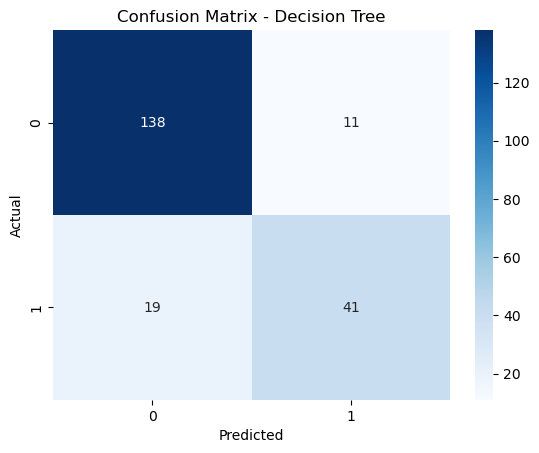

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()


# 13. Model Comparison

In [34]:
models = ["KNN","Naive Bayes","Decision Tree"]
accuracy_scores = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_dt)
]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy_scores
})

comparison


,Model,Accuracy
0,KNN,0.832536
1,Naive Bayes,0.822967
2,Decision Tree,0.856459


# 14. Conclusion

This project analyzed student academic and behavioral data to predict final performance and dropout risk.

The regression model was used to predict final grades, while classification models such as KNN, Naive Bayes, and Decision Tree were used to identify students at risk of dropping out.

The results indicate that variables such as previous grades, study time, failures, and absences significantly influence student performance. Among the classification models tested, the Decision Tree achieved the best accuracy for dropout prediction.

These insights can help educational institutions identify at-risk students early and provide academic support.
